<a href="https://colab.research.google.com/github/ZiQing-ui/Project/blob/main/Low_Zi_Qing_Model_(v2).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install optuna

  Using cached optuna-4.7.0-py3-none-any.whl.metadata (17 kB)
  Using cached colorlog-6.10.1-py3-none-any.whl.metadata (11 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 413.9/413.9 kB 6.2 MB/s eta 0:00:00


# Set Reproduction Seeds & Parameters

In [ ]:
# Neccessary Import
import numpy as np
import tensorflow as tf
import pandas as pd
import random
import os
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Model, load_model
from tensorflow.keras.layers import Input, GRU, Dense, RepeatVector, TimeDistributed, Attention, Concatenate
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

In [ ]:
# ==========================================
# 1. REPRODUCIBILITY SEEDS
# ==========================================
SEED = 42

def set_reproducibility(seed_value):
    os.environ['PYTHONHASHSEED'] = str(seed_value)
    random.seed(seed_value)
    np.random.seed(seed_value)
    tf.random.set_seed(seed_value)

    # Force TensorFlow to use deterministic algorithms (optional but recommended)
    os.environ['TF_DETERMINISTIC_OPS'] = '1'
    os.environ['TF_CUDNN_DETERMINISTIC'] = '1'

set_reproducibility(SEED)

In [ ]:
# ==========================================
# 2. DATA & FEATURE PARAMETERS
# ==========================================
CSV_PATH     = "final_processed_food_loss.csv"
ID_COL       = "Item_Name"
TIME_COL     = "Year"
TARGET       = "Losses"

# Hybrid Feature Set: Domain Drivers + STL Components
FEATURE_CANDIDATES = [
    # Domain Drivers (Agricultural Context)
    "Domestic_Supply", "Export", "Feed", "Import",
    "Other uses (non-food)", "Processing", "Production", "Residuals",
    "Seed", "Stock_Variation", "Population",
    "SSR (%)", "IDR (%)", "Domestic_Availability",

    # STL Components (Time-Series Structure)
    "Trend_Scaled", "Seasonal_Scaled", "Resid_Scaled", "Is_Outlier"
]

# ==========================================
# 3. WINDOWING (Seq2Seq) PARAMETERS
# ==========================================
T_IN  = 5    # Lookback: Past 5 years of history
T_OUT = 3    # Forecast Horizon: Predict next 3 years as a block

# Temporal split ratios per item
TRAIN_RATIO = 0.70
VAL_RATIO   = 0.15
TEST_RATIO  = 0.15

# ==========================================
# 4. MODEL HYPERPARAMETERS
# ==========================================
GRU_UNITS_1  = 128
GRU_UNITS_2  = 64
DENSE_UNITS  = 32
DROPOUT_RATE = 0.40

BATCH_SIZE    = 8
EPOCHS        = 200
LEARNING_RATE = 1e-3
CLIPNORM      = 1.0

# ==========================================
# 5. SOFT-DTW / HYBRID LOSS PARAMETERS
# ==========================================
GAMMA = 0.05    # Smoothing parameter for Soft-DTW
BAND  = T_OUT   # Sakoe–Chiba band constraint
ALPHA = 0.60    # Weight balance (Hybrid Loss = ALPHA*DTW + (1-ALPHA)*MSE)

# ==========================================
# 6. DIRECTORY SETUP
# ==========================================
SAVE_DIR = "gru_hybrid_dtw_output"
os.makedirs(SAVE_DIR, exist_ok=True)

print(f"✅ Configuration Initialized with {len(FEATURE_CANDIDATES)} Hybrid Features.")
print(f"📂 Output directory created: {SAVE_DIR}")

✅ Configuration Initialized with 18 Hybrid Features.
📂 Output directory created: gru_hybrid_dtw_output


# Data Scaling & Create Functions

In [ ]:
# Load and Filter Features
df = pd.read_csv(CSV_PATH)

df['Losses_Log'] = np.log1p(df[TARGET])
# Update the TARGET variable pointer to use the log-transformed column
TARGET = 'Losses_Log'

# Adding lag
df = df.sort_values([ID_COL, TIME_COL])
df['Loss_Lag1'] = df.groupby(ID_COL)[TARGET].shift(1)

# Create the scalers
scaler_domain = StandardScaler()
target_scaler = StandardScaler()

# Identify domain features (excluding STL which are already scaled)
# We focus on the raw agricultural and population data
domain_features = [
    "Domestic_Supply", "Export", "Feed", "Import", "Other uses (non-food)",
    "Processing", "Production", "Residuals", "Seed", "Stock_Variation",
    "Population", "SSR (%)", "IDR (%)", "Domestic_Availability", "Loss_Lag1"
]

# Ensure we only attempt to scale columns that actually exist
cols_to_scale = [c for c in domain_features if c in df.columns]

# Apply scaling to the features (X)
df[cols_to_scale] = scaler_domain.fit_transform(df[cols_to_scale].fillna(0))

# Apply scaling specifically to the Target (y)
# This is crucial so we can do 'target_scaler.inverse_transform' later
df[[TARGET]] = target_scaler.fit_transform(df[[TARGET]].fillna(0))

print(f"✅ Data Normalized: {len(cols_to_scale)} features and target variable scaled.")

available_features = [f for f in FEATURE_CANDIDATES if f in df.columns]

✅ Data Normalized: 15 features and target variable scaled.


In [ ]:
display(df)

,Year,Item,Domestic_Supply,Export,Feed,Import,Losses,Other uses (non-food),Processing,Production,...,Domestic_Availability,PerCapita_Availability,PerCapita_Availability_kg,Is_Outlier,Trend_Scaled,Seasonal_Scaled,Resid_Scaled,Item_Name,Losses_Log,Loss_Lag1
0,2010-01-01,Bananas,-0.245510,-0.234658,-0.211165,-0.442187,58.0,-0.309058,-0.207552,-0.233686,...,-0.245930,0.010958,10.96,0,-1.843773,2.078927,0.059222,Bananas,0.889271,-1.122575
1,2011-01-01,Bananas,-0.247012,-0.233928,-0.211165,-0.442187,53.0,-0.309058,-0.207552,-0.235184,...,-0.247558,0.009773,9.77,0,-1.565712,0.344243,-0.694034,Bananas,0.843116,0.967310
2,2012-01-01,Bananas,-0.247402,-0.235752,-0.211165,-0.438980,51.0,-0.309058,-0.207552,-0.236127,...,-0.247895,0.009406,9.41,0,-1.266172,-1.224718,0.270536,Bananas,0.823445,0.921923
3,2013-01-01,Bananas,-0.247012,-0.235387,-0.211165,-0.434704,53.0,-0.309058,-0.207552,-0.236127,...,-0.247502,0.009478,9.48,0,-0.945288,-0.675020,0.043519,Bananas,0.843116,0.902580
4,2014-01-01,Bananas,-0.246011,-0.234658,-0.211165,-0.432032,56.0,-0.309058,-0.207552,-0.235351,...,-0.246547,0.009871,9.87,0,-0.565636,1.163770,-0.675160,Bananas,0.871296,0.921923
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
373,2019-01-01,Yams,-0.262707,-0.242316,-0.211165,-0.440583,0.0,-0.309058,-0.207552,-0.252163,...,-0.263277,0.000150,0.15,0,-0.043110,0.057118,-1.510383,Yams,-1.236002,-1.122575
374,2020-01-01,Yams,-0.262707,-0.242316,-0.211165,-0.440583,0.0,-0.309058,-0.207552,-0.252163,...,-0.263277,0.000148,0.15,0,-0.066662,-1.511246,0.630424,Yams,-1.236002,-1.122575
375,2021-01-01,Yams,-0.262317,-0.241951,-0.211165,-0.440049,1.0,-0.309058,-0.207552,-0.251830,...,-0.262940,0.000321,0.32,0,0.835403,1.983887,0.630425,Yams,-0.874723,-1.122575
376,2022-01-01,Yams,-0.262373,-0.241951,-0.211165,-0.440583,1.0,-0.309058,-0.207552,-0.251774,...,-0.262940,0.000317,0.32,0,1.737460,-0.045085,0.630466,Yams,-0.874723,-0.767312


In [ ]:
# Save the processed DataFrame to a CSV file
df.to_csv("processed_scaled_data.csv", index=False)
print("✅ DataFrame 'df' saved to 'processed_scaled_data.csv'")

✅ DataFrame 'df' saved to 'processed_scaled_data.csv'


In [ ]:
def create_seq2seq_windows(data, features, target_col, time_steps=5, horizon=3):
    X, y, years = [], [], []

    # 1. Fill NaNs caused by differencing or missing data
    data = data.copy()
    data[features] = data[features].fillna(0)
    data[target_col] = data[target_col].fillna(0)

    data = data.sort_values(TIME_COL).reset_index(drop=True)
    yrs = pd.to_datetime(data[TIME_COL]).dt.year.values

    if len(data) < time_steps + horizon:
        return None

    for i in range(time_steps, len(data) - horizon + 1):
        # 2. Validate consecutive years for the horizon
        future_years = yrs[i : i + horizon]
        if np.any(np.diff(future_years) != 1):
            continue

        x_val = data[features].iloc[i - time_steps : i].values
        y_val = data[[target_col]].iloc[i : i + horizon].values

        # 3. Final NaN check to ensure array stacking stability
        if np.isnan(x_val).any() or np.isnan(y_val).any():
            continue

        X.append(x_val)
        y.append(y_val)
        years.append(yrs[i])

    if not X: return None
    return np.stack(X), np.stack(y), np.array(years)

# Containers for splits and metadata for plotting
X_tr_list, y_tr_list, X_va_list, y_va_list, X_te_list, y_te_list = [], [], [], [], [], []
IT_te_list, YR_te_list = [], []

for item in df[ID_COL].unique():
    item_df = df[df[ID_COL] == item]
    result = create_seq2seq_windows(item_df, available_features, TARGET, T_IN, T_OUT)
    if result is None: continue
    Xi, yi, yrsi = result

    n = len(Xi)
    n_tr, n_va = int(n * TRAIN_RATIO), int(n * VAL_RATIO)

    X_tr_list.append(Xi[:n_tr]); y_tr_list.append(yi[:n_tr])
    X_va_list.append(Xi[n_tr:n_tr+n_va]); y_va_list.append(yi[n_tr:n_tr+n_va])

    # Save test set with metadata for evaluation plots
    X_te, y_te, yr_te = Xi[n_tr+n_va:], yi[n_tr+n_va:], yrsi[n_tr+n_va:]
    X_te_list.append(X_te); y_te_list.append(y_te)
    IT_te_list += [item] * len(X_te)
    YR_te_list += list(yr_te)

# Final Tensor Preparation
X_train, y_train = np.concatenate(X_tr_list), np.concatenate(y_tr_list)
X_val, y_val     = np.concatenate(X_va_list), np.concatenate(y_va_list)
X_test, y_test   = np.concatenate(X_te_list), np.concatenate(y_te_list)

print(f"Windows formed:")
print(f"  X_train {X_train.shape}, y_train {y_train.shape}")
print(f"  X_val   {X_val.shape},   y_val   {y_val.shape}")
print(f"  X_test  {X_test.shape},  y_test  {y_test.shape}")

print(f"\nFinal splits (after fallback):")
print(f"  Train: {X_train.shape[0]} samples")
print(f"  Val:   {X_val.shape[0]} samples")
print(f"  Test:  {X_test.shape[0]} samples")

Windows formed:
  X_train (108, 5, 18), y_train (108, 3, 1)
  X_val   (27, 5, 18),   y_val   (27, 3, 1)
  X_test  (54, 5, 18),  y_test  (54, 3, 1)

Final splits (after fallback):
  Train: 108 samples
  Val:   27 samples
  Test:  54 samples


In [ ]:
from tensorflow.keras.layers import GlobalAveragePooling1D, Dropout, BatchNormalization

def build_attention_seq2seq(input_shape, horizon, units=128, dr=0.4):
    encoder_inputs = Input(shape=input_shape)

    # 1. Encoder
    # We use return_sequences=True to feed the Attention layer
    encoder_gru, state_h = GRU(units, return_sequences=True, return_state=True)(encoder_inputs)

    # --- GLOBAL CONTEXT BRANCH ---
    # Captures the 5-year trend average
    global_context = GlobalAveragePooling1D()(encoder_gru)

    # ADDED: Dropout specifically for the global context to prevent overfitting to averages
    global_context = Dropout(dr)(global_context)

    # Repeated to match the decoder's time horizon
    global_context_repeated = RepeatVector(horizon)(global_context)
    # -----------------------------

    # 2. Decoder Initial State Setup
    decoder_initial_state = Dense(units//2, activation='tanh')(state_h)
    decoder_input = RepeatVector(horizon)(decoder_initial_state)

    # 3. Decoder GRU
    decoder_gru = GRU(units//2, return_sequences=True)(decoder_input, initial_state=decoder_initial_state)

    # 4. Attention Mechanism
    encoder_out_proj = TimeDistributed(Dense(units//2, activation='relu'))(encoder_gru)
    attn_layer = Attention()([decoder_gru, encoder_out_proj])

    # 5. CONCATENATION: Local (Attention) + Global (Pooled) + Temporal (Decoder)
    decoder_combined = Concatenate()([decoder_gru, attn_layer, global_context_repeated])

    # ADDED: BatchNormalization and final Dropout before prediction
    # This helps stabilize the large values created by Concatenate
    decoder_combined = BatchNormalization()(decoder_combined)
    decoder_combined = Dropout(dr)(decoder_combined)

    # 6. Final Output (TimeDistributed for each year in horizon)
    output = TimeDistributed(Dense(1))(decoder_combined)

    return Model(inputs=encoder_inputs, outputs=output)

# Instantiate the final thesis-model
model = build_attention_seq2seq((T_IN, len(available_features)), T_OUT, units=128, dr=0.5)
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 5, 18)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gru (GRU)           │ [(None, 5, 128),  │     56,832 │ input_layer[0][0] │
│                     │ (None, 128)]      │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 64)        │      8,256 │ gru[0][1]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ repeat_vector_1     │ (None, 3, 64)     │          0 │ dense[0][0]       │
│ (RepeatVector)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 128)       │          0 │ gru[0][0]         │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gru_1 (GRU)         │ (None, 3, 64)     │     24,960 │ repeat_vector_1[… │
│                     │                   │            │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed    │ (None, 5, 64)     │      8,256 │ gru[0][0]         │
│ (TimeDistributed)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 128)       │          0 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attention           │ (None, 3, 64)     │          0 │ gru_1[0][0],      │
│ (Attention)         │                   │            │ time_distributed… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ repeat_vector       │ (None, 3, 128)    │          0 │ dropout[0][0]     │
│ (RepeatVector)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 3, 256)    │          0 │ gru_1[0][0],      │
│ (Concatenate)       │                   │            │ attention[0][0],  │
│                     │                   │            │ repeat_vector[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 3, 256)    │      1,024 │ concatenate[0][0] │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 3, 256)    │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed_1  │ (None, 3, 1)      │        257 │ dropout_1[0][0]   │
│ (TimeDistributed)   │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 99,585 (389.00 KB)

 Trainable params: 99,073 (387.00 KB)

 Non-trainable params: 512 (2.00 KB)

In [ ]:
import joblib

# 1. Capture the 19 final features
available_features = [f for f in FEATURE_CANDIDATES if f in df.columns] #

# 2. Windowing (Converts DF to 3D Tensors)
# Use your previously defined create_seq2seq_windows function here

# 3. Create the Scaled Tensors (Fixes the NameError)
feat_scaler = StandardScaler() #
tgt_scaler  = StandardScaler() #

# Reshape for scaling logic
n_feat = X_train.shape[2] #
X_train_scaled = feat_scaler.fit_transform(X_train.reshape(-1, n_feat)).reshape(X_train.shape)
X_val_scaled   = feat_scaler.transform(X_val.reshape(-1, n_feat)).reshape(X_val.shape)
X_test_scaled  = feat_scaler.transform(X_test.reshape(-1, n_feat)).reshape(X_test.shape)

y_train_scaled = tgt_scaler.fit_transform(y_train.reshape(-1, 1)).reshape(y_train.shape)
y_val_scaled   = tgt_scaler.transform(y_val.reshape(-1, 1)).reshape(y_val.shape)
y_test_scaled  = tgt_scaler.transform(y_test.reshape(-1, 1)).reshape(y_test.shape)

# 4. Save Scalers (Critical for your 2024-2026 Prediction script)
joblib.dump(feat_scaler, os.path.join(SAVE_DIR, "feature_scaler.pkl")) #
joblib.dump(tgt_scaler,  os.path.join(SAVE_DIR, "target_scaler.pkl")) #

['gru_hybrid_dtw_output/target_scaler.pkl']

# Optimization & Fine-tuning

In [ ]:
import optuna
import tensorflow as tf
from tensorflow.keras.backend import clear_session

def objective(trial):
    # 1. Clear memory but re-apply the seed to ensure local trial consistency
    clear_session()
    tf.random.set_seed(SEED)

    # 2. Search Space
    lr = trial.suggest_float("lr", 1e-4, 1e-2, log=True)
    batch_size = trial.suggest_categorical("batch_size", [4, 8, 16])
    gru_units = trial.suggest_int("gru_units", 64, 256, step=64)
    dropout = trial.suggest_float("dropout", 0.1, 0.5)

    # 3. Build Model
    model = build_attention_seq2seq(
        input_shape=(T_IN, len(available_features)),
        horizon=T_OUT,
        units=gru_units,
        dr=dropout
    )

    optimizer = tf.keras.optimizers.Adam(learning_rate=lr)
    model.compile(optimizer=optimizer, loss='mse')

    # 4. Train on SCALED data
    history = model.fit(
        X_train_scaled, y_train_scaled,
        validation_data=(X_val_scaled, y_val_scaled),
        epochs=30,
        batch_size=batch_size,
        shuffle=False, # Set shuffle to False or use a seeded shuffler
        verbose=0,
        callbacks=[tf.keras.callbacks.EarlyStopping(patience=5)]
    )

    val_loss = min(history.history['val_loss'])
    return np.sqrt(val_loss)

# --- Run the Seeded Study ---
# We use TPESampler with a seed so Optuna's "guesses" are deterministic
study = optuna.create_study(
    direction="minimize",
    sampler=optuna.samplers.TPESampler(seed=SEED)
)
study.optimize(objective, n_trials=20)

print("\n🏆 Best Trial Found:")
print(f"  Value (RMSE): {study.best_value}")
print(f"  Params: {study.best_params}")

[I 2026-03-07 09:54:30,803] A new study created in memory with name: no-name-64093141-7ea9-42bc-9704-7ffe2c586eb2
[I 2026-03-07 09:54:55,467] Trial 0 finished with value: 0.8499125323451403 and parameters: {'lr': 0.0005611516415334506, 'batch_size': 4, 'gru_units': 64, 'dropout': 0.16239780813448107}. Best is trial 0 with value: 0.8499125323451403.
[I 2026-03-07 09:55:04,697] Trial 1 finished with value: 0.9822504641055329 and parameters: {'lr': 0.00013066739238053285, 'batch_size': 4, 'gru_units': 64, 'dropout': 0.4879639408647978}. Best is trial 0 with value: 0.8499125323451403.
[I 2026-03-07 09:55:12,291] Trial 2 finished with value: 0.9836531823392166 and parameters: {'lr': 0.004622589001020831, 'batch_size': 4, 'gru_units': 128, 'dropout': 0.3099025726528951}. Best is trial 0 with value: 0.8499125323451403.
[I 2026-03-07 09:55:26,962] Trial 3 finished with value: 0.7953212025584082 and parameters: {'lr': 0.0007309539835912913, 'batch_size': 8, 'gru_units': 128, 'dropout': 0.246544


🏆 Best Trial Found:
  Value (RMSE): 0.5750770641597482
  Params: {'lr': 0.008513537594102777, 'batch_size': 16, 'gru_units': 256, 'dropout': 0.4044273299427489}


In [ ]:
import json
import os

# Save the best_params to a JSON file
best_params_path = os.path.join(SAVE_DIR, "best_params.json")
with open(best_params_path, "w") as f:
    json.dump(study.best_params, f, indent=4)

print(f"✅ Best parameters saved to: {best_params_path}")

✅ Best parameters saved to: gru_hybrid_dtw_output/best_params.json


In [ ]:
# 1. Retrieve the winning parameters
best_params = study.best_params
print(f"🚀 Training final model with: {best_params}")

# 2. Build and Compile the final model
model = build_attention_seq2seq(
    input_shape=(T_IN, len(available_features)),
    horizon=T_OUT,
    units=best_params['gru_units'],
    dr=best_params['dropout']
)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=best_params['lr']),
    loss='mse',
    metrics=['mae']
)

# 4. Define Callbacks (Your current logic is correct)
callbacks = [
    EarlyStopping(monitor='val_loss', patience=25, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=10, min_lr=1e-6, verbose=1),
    ModelCheckpoint(os.path.join(SAVE_DIR, "best_model.keras"), monitor='val_loss', save_best_only=True)
]

# 5. Final Training Session
# IMPORTANT: Use the _scaled versions of your data created earlier
print("🚀 Starting Optimized Hybrid GRU-Attention Training...")
history = model.fit(
    X_train_scaled, y_train_scaled,
    validation_data=(X_val_scaled, y_val_scaled),
    epochs=200,
    batch_size=best_params['batch_size'],
    callbacks=callbacks,
    verbose=1
)

history_path = os.path.join(SAVE_DIR, "hist_best.json")

# Convert history dict values to float (required for JSON serializing)
history_dict = {k: [float(val) for val in v] for k, v in history.history.items()}

with open(history_path, "w") as f:
    json.dump(history_dict, f)

# 5. Save Best Params for reference
with open(os.path.join(SAVE_DIR, "best_params.json"), "w") as f:
    json.dump(best_params, f)

print(f"✅ Final training history and params saved to {SAVE_DIR}")

🚀 Training final model with: {'lr': 0.008513537594102777, 'batch_size': 16, 'gru_units': 256, 'dropout': 0.4044273299427489}
🚀 Starting Optimized Hybrid GRU-Attention Training...
Epoch 1/200
7/7 ━━━━━━━━━━━━━━━━━━━━ 8s 176ms/step - loss: 17.0325 - mae: 2.6188 - val_loss: 0.8909 - val_mae: 0.7825 - learning_rate: 0.0085
Epoch 2/200
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 3.0524 - mae: 1.3376 - val_loss: 1.2015 - val_mae: 0.8825 - learning_rate: 0.0085
Epoch 3/200
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 2.0308 - mae: 1.1002 - val_loss: 2.3399 - val_mae: 1.3406 - learning_rate: 0.0085
Epoch 4/200
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 2.1153 - mae: 1.1428 - val_loss: 1.9692 - val_mae: 1.2263 - learning_rate: 0.0085
Epoch 5/200
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 1.5354 - mae: 0.9473 - val_loss: 1.4021 - val_mae: 0.9171 - learning_rate: 0.0085
Epoch 6/200
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 1.5702 - mae: 0.9198 - val_loss: 2.1456 - val_mae: 1.2656 - l

In [ ]:
# 1. Generate predictions
y_pred_scaled = model.predict(X_test_scaled)

# 2. Inverse Transform: Scaling -> then Exponential (to reverse Log)
# First, move from Standardized back to Log units
y_true_log = tgt_scaler.inverse_transform(y_test_scaled.reshape(-1, 1)).flatten()
y_pred_log = tgt_scaler.inverse_transform(y_pred_scaled.reshape(-1, 1)).flatten()

# Second, move from Log units back to Real Tonnes
y_true_final = np.expm1(y_true_log)
y_pred_final = np.expm1(y_pred_log)

# 3. Calculate Final Metrics
rmse = np.sqrt(mean_squared_error(y_true_final, y_pred_final))
mae = mean_absolute_error(y_true_final, y_pred_final)
r2 = r2_score(y_true_final, y_pred_final)

print(f"Test RMSE: {rmse:.2f} Tonnes")
print(f"Test MAE:  {mae:.2f} Tonnes")
print(f"R² Score:  {r2:.4f}")

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 538ms/step
Test RMSE: 0.88 Tonnes
Test MAE:  0.64 Tonnes
R² Score:  0.8581


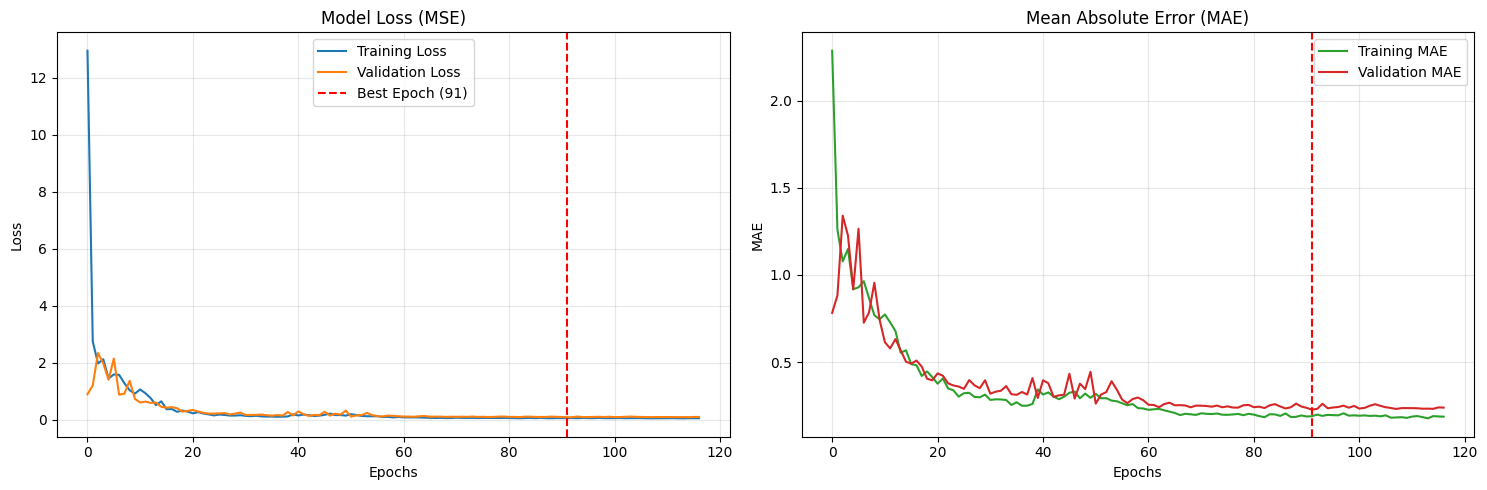

In [ ]:
# Load the saved JSON
with open(os.path.join(SAVE_DIR, "hist_best.json"), "r") as f:
    h = json.load(f)

# Find where the best model was actually saved
best_epoch = h["val_loss"].index(min(h["val_loss"]))

def plot_learning_curves(h):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

    # --- Loss Plot (MSE) ---
    ax1.plot(h["loss"], label="Training Loss", color='#1f77b4')
    ax1.plot(h["val_loss"], label="Validation Loss", color='#ff7f0e')
    ax1.axvline(best_epoch, color='red', linestyle='--', label=f'Best Epoch ({best_epoch})')
    ax1.set_title("Model Loss (MSE)")
    ax1.set_xlabel("Epochs")
    ax1.set_ylabel("Loss")
    ax1.legend()
    ax1.grid(alpha=0.3)

    # --- MAE Plot ---
    if "mae" in h:
        ax2.plot(h["mae"], label="Training MAE", color='#2ca02c')
        ax2.plot(h["val_mae"], label="Validation MAE", color='#d62728')
        ax2.axvline(best_epoch, color='red', linestyle='--')
        ax2.set_title("Mean Absolute Error (MAE)")
        ax2.set_xlabel("Epochs")
        ax2.set_ylabel("MAE")
        ax2.legend()
        ax2.grid(alpha=0.3)
    # plt.yscale('log')
    plt.tight_layout()
    plt.show()

plot_learning_curves(h)

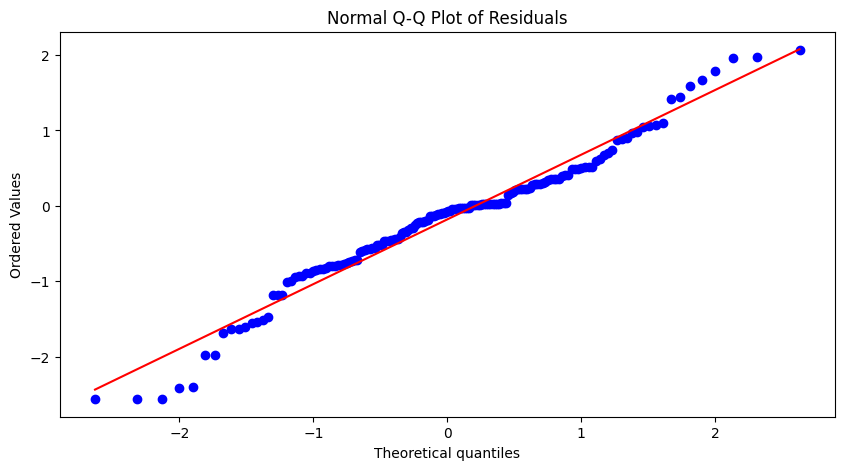

In [ ]:
import scipy.stats as stats
residuals = y_true_final - y_pred_final
plt.figure(figsize=(10, 5))
stats.probplot(residuals, dist="norm", plot=plt)
plt.title("Normal Q-Q Plot of Residuals")
plt.show()

In [ ]:
# 1. Verification Check
# Run this right after your big loop to see where the mismatch is
print(f"Total Test Windows: {X_test.shape[0]}")
print(f"Item Metadata List Length: {len(IT_te_list)}")
print(f"Year Metadata List Length: {len(YR_te_list)}")

# 2. Alignment Fix
# If the lengths don't match, re-run the loop with this safer logic:
IT_te_list, YR_te_list = [], []

for item in df[ID_COL].unique():
    item_df = df[df[ID_COL] == item]
    result = create_seq2seq_windows(item_df, available_features, TARGET, T_IN, T_OUT)
    if result is None: continue

    Xi, yi, yrsi = result
    n = len(Xi)
    n_tr, n_va = int(n * TRAIN_RATIO), int(n * VAL_RATIO)

    # Extract the test portion
    X_te = Xi[n_tr+n_va:]
    yr_te = yrsi[n_tr+n_va:]

    # ONLY append to metadata if the test set actually has samples
    if len(X_te) > 0:
        IT_te_list.extend([item] * len(X_te))
        YR_te_list.extend(list(yr_te))

# 3. Final Conversion
IT_te_arr = np.array(IT_te_list)
YR_te_arr = np.array(YR_te_list)

Total Test Windows: 54
Item Metadata List Length: 54
Year Metadata List Length: 54


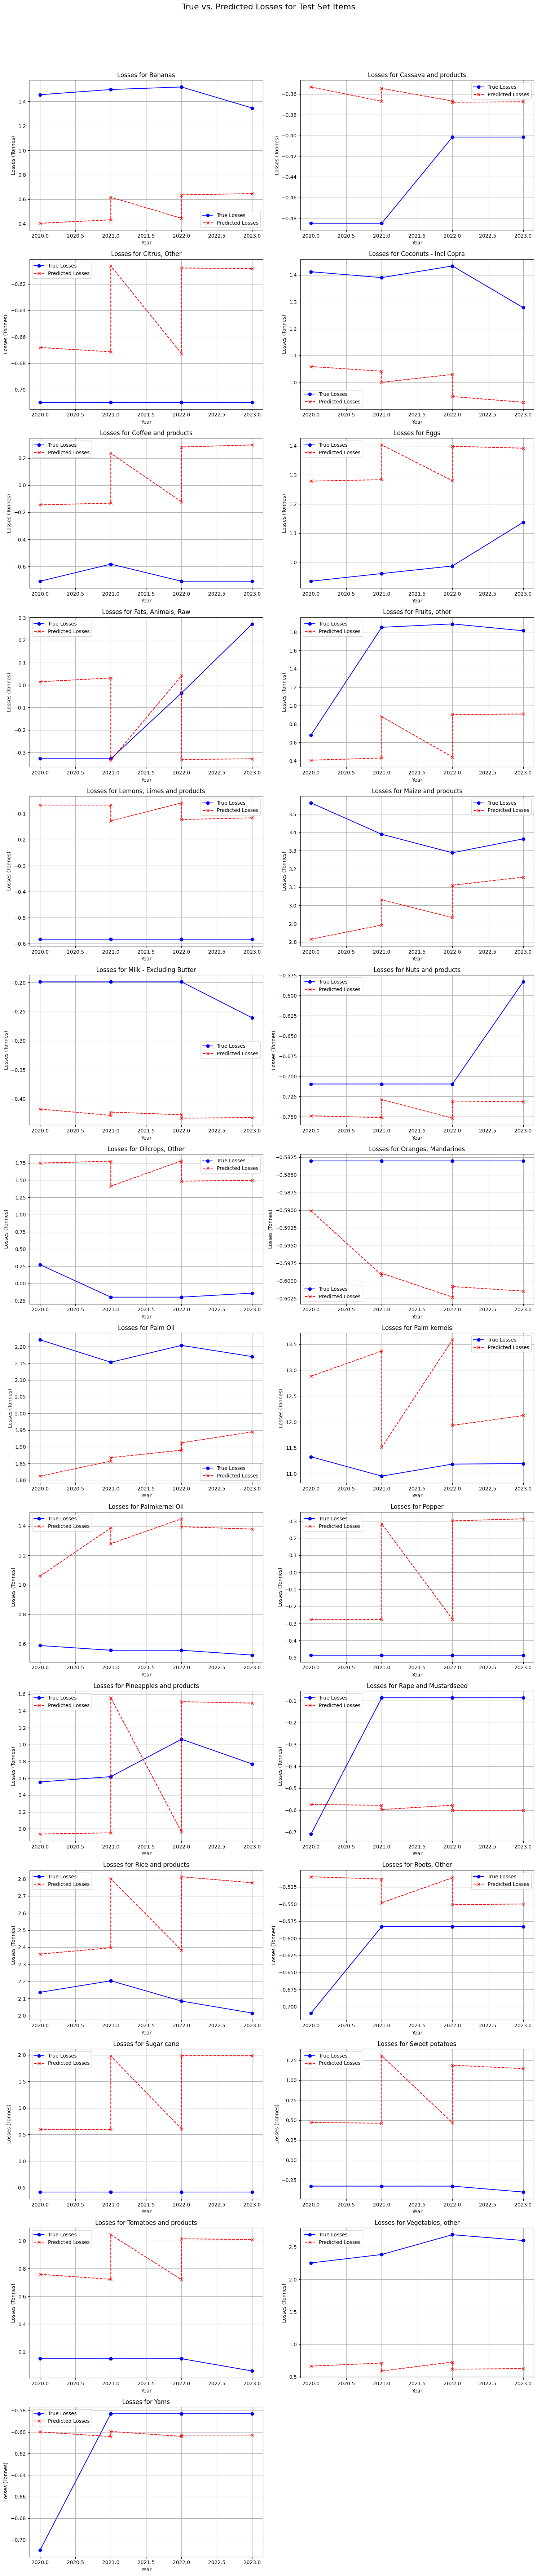

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# 1. Reshape y_true_final and y_pred_final
# X_test.shape[0] gives the total number of test windows/samples
num_test_windows = X_test.shape[0]
y_true_reshaped = y_true_final.reshape(num_test_windows, T_OUT)
y_pred_reshaped = y_pred_final.reshape(num_test_windows, T_OUT)

# 2. Create a DataFrame for plotting
plot_data = []
for i in range(num_test_windows):
    item_name = IT_te_arr[i] # IT_te_arr was created in cell 'qysat6ArFZku'
    start_year = YR_te_arr[i] # YR_te_arr was created in cell 'qysat6ArFZku'
    for j in range(T_OUT):
        plot_data.append({
            "Item_Name": item_name,
            "Year": start_year + j,
            "True_Losses": y_true_reshaped[i, j],
            "Predicted_Losses": y_pred_reshaped[i, j]
        })

plot_df = pd.DataFrame(plot_data)

# 3. Visualize the results for each unique item
unique_items = plot_df["Item_Name"].unique()
n_items = len(unique_items)

# Determine grid size for subplots
nrows = int(np.ceil(n_items / 2)) # 2 columns per row
ncols = 2

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(15, nrows * 5), layout='tight')
axes = axes.flatten() # Flatten for easy iteration

for i, item_name in enumerate(unique_items):
    ax = axes[i]
    item_plot_df = plot_df[plot_df["Item_Name"] == item_name].sort_values("Year")

    ax.plot(item_plot_df["Year"], item_plot_df["True_Losses"], label="True Losses", marker='o', linestyle='-', color='blue')
    ax.plot(item_plot_df["Year"], item_plot_df["Predicted_Losses"], label="Predicted Losses", marker='x', linestyle='--', color='red')

    ax.set_title(f"Losses for {item_name}")
    ax.set_xlabel("Year")
    ax.set_ylabel("Losses (Tonnes)")
    ax.legend()
    ax.grid(True)

# Turn off any unused subplots
for i in range(n_items, len(axes)):
    fig.delaxes(axes[i])

plt.suptitle("True vs. Predicted Losses for Test Set Items", fontsize=16, y=1.02)
plt.show()

# Others checking

In [ ]:
def check_temporal_leakage(X, y, years, t_in, horizon):
    """
    Checks if the generated sequences contain overlapping years or future look-ahead.
    """
    print("🔍 Starting Temporal Leakage Diagnostic...")
    leakage_found = False

    # Check a random sample of 5 windows
    indices = np.random.choice(len(X), size=min(5, len(X)), replace=False)

    for idx in indices:
        # The 'years' array typically holds the year the prediction starts
        start_prediction_year = years[idx]

        # In a valid windowing system:
        # Input sequence (X) should represent years [start - t_in : start]
        # Target sequence (y) should represent years [start : start + horizon]

        print(f"\n--- Checking Window {idx} ---")
        print(f"Prediction starts in: {int(start_prediction_year)}")

        # Verify the Gap
        # If your 'years' represents the first year of the target 'y':
        # The last year in 'X' must be strictly less than 'years[idx]'

        # Logic Check:
        # If input sequence contains 2023 data to predict 2023 loss, that is LEAKAGE.
        # Input must end at 2022 to predict 2023.

        # 1. Check for Duplicate Target values in Features
        # (Assuming the target column is the first feature or specifically named)
        if np.array_equal(X[idx, -1, 0], y[idx, 0, 0]):
            print("❌ WARNING: The last input value is identical to the first target value.")
            print("   This suggests the model already 'knows' the answer it is trying to predict.")
            leakage_found = True
        else:
            print("✅ Input and Target values are distinct.")

    if not leakage_found:
        print("\n🏆 Result: No obvious temporal leakage detected in the sample windows.")
    else:
        print("\n⚠️ Result: Potential leakage detected. Review your create_seq2seq_windows logic.")

YR_tr_list = []
for item in df[ID_COL].unique():
    item_df = df[df[ID_COL] == item]
    result = create_seq2seq_windows(item_df, available_features, TARGET, T_IN, T_OUT)
    if result is not None:
        Xi, yi, yrsi = result
        n_tr = int(len(Xi) * TRAIN_RATIO)
        YR_tr_list.extend(list(yrsi[:n_tr]))

# 2. Run the check on the Training Set
check_temporal_leakage(X_train, y_train, YR_tr_list, T_IN, T_OUT)

🔍 Starting Temporal Leakage Diagnostic...

--- Checking Window 77 ---
Prediction starts in: 2016
✅ Input and Target values are distinct.

--- Checking Window 10 ---
Prediction starts in: 2017
✅ Input and Target values are distinct.

--- Checking Window 4 ---
Prediction starts in: 2015
✅ Input and Target values are distinct.

--- Checking Window 83 ---
Prediction starts in: 2018
✅ Input and Target values are distinct.

--- Checking Window 62 ---
Prediction starts in: 2017
✅ Input and Target values are distinct.

🏆 Result: No obvious temporal leakage detected in the sample windows.


# Prediction

In [ ]:
import joblib

# Create a dictionary to hold all your preprocessing objects
metadata = {
    "scaler_domain": scaler_domain,
    "target_scaler": target_scaler,
    "available_features": available_features,
    "T_IN": T_IN,
    "T_OUT": T_OUT,
    "ID_COL": ID_COL,
    "TIME_COL": TIME_COL,
    "TARGET": TARGET
}

metadata_path = os.path.join(SAVE_DIR, "model_metadata.joblib")
joblib.dump(metadata, metadata_path)

print(f"✅ Metadata and Scalers saved to: {metadata_path}")

✅ Metadata and Scalers saved to: gru_hybrid_dtw_output/model_metadata.joblib


In [ ]:
# --- 1. LOAD ASSETS ---
# Ensure these paths match your SAVE_DIR structure
METADATA_PATH = os.path.join("gru_hybrid_dtw_output", "model_metadata.joblib")
MODEL_PATH    = os.path.join("gru_hybrid_dtw_output", "best_model.keras")
DATA_PATH     = "processed_scaled_data.csv" # Your raw input data

# Load Metadata
meta = joblib.load(METADATA_PATH)
scaler_domain = meta["scaler_domain"]
target_scaler = meta["target_scaler"]
available_features = meta["available_features"]
T_IN = meta["T_IN"]
ID_COL = meta["ID_COL"]
TIME_COL = meta["TIME_COL"]

# Load Model
model = load_model(MODEL_PATH)

# Load Data
df_original = pd.read_csv(CSV_PATH)

# --- THE FIX: Replicate the Training Preprocessing ---
# 1. Create the Log-Transformed target column (must match the name in metadata)
# Assuming 'Losses' is the original column name in your CSV
df_original['Losses_Log'] = np.log1p(df_original['Losses'])

# 2. Now create the Lag feature using the Log-Transformed column
# TARGET here refers to 'Losses_Log' from your meta["TARGET"]
df_original = df_original.sort_values([ID_COL, TIME_COL])
df_original['Loss_Lag1'] = df_original.groupby(ID_COL)[TARGET].shift(1).fillna(0)

# --- CONTINUE WITH SCALING ---
# Now 'Loss_Lag1' is based on log units, which is what your scaler_domain expects
df_scaled = df_original.copy()
df_scaled[cols_to_scale] = scaler_domain.transform(df_scaled[cols_to_scale].fillna(0))

print("✅ Assets loaded and data pre-processed successfully.")

✅ Assets loaded and data pre-processed successfully.


<Axes: xlabel='Item'>

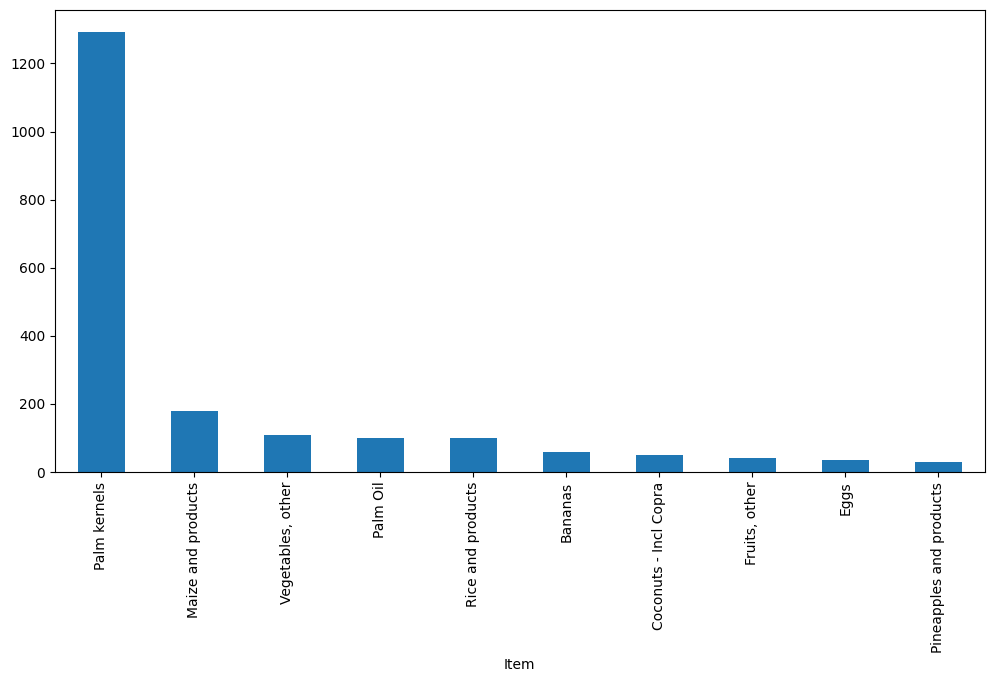

In [ ]:
top10_items = (
    df.groupby("Item")["Losses"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)
top10_items.plot(kind="bar", figsize=(12, 6), color='#1f77b4')

📌 Generating Thesis Grid for: ['Palm kernels', 'Maize and products', 'Vegetables, other', 'Palm Oil', 'Rice and products', 'Bananas', 'Coconuts - Incl Copra', 'Fruits, other', 'Eggs', 'Pineapples and products']


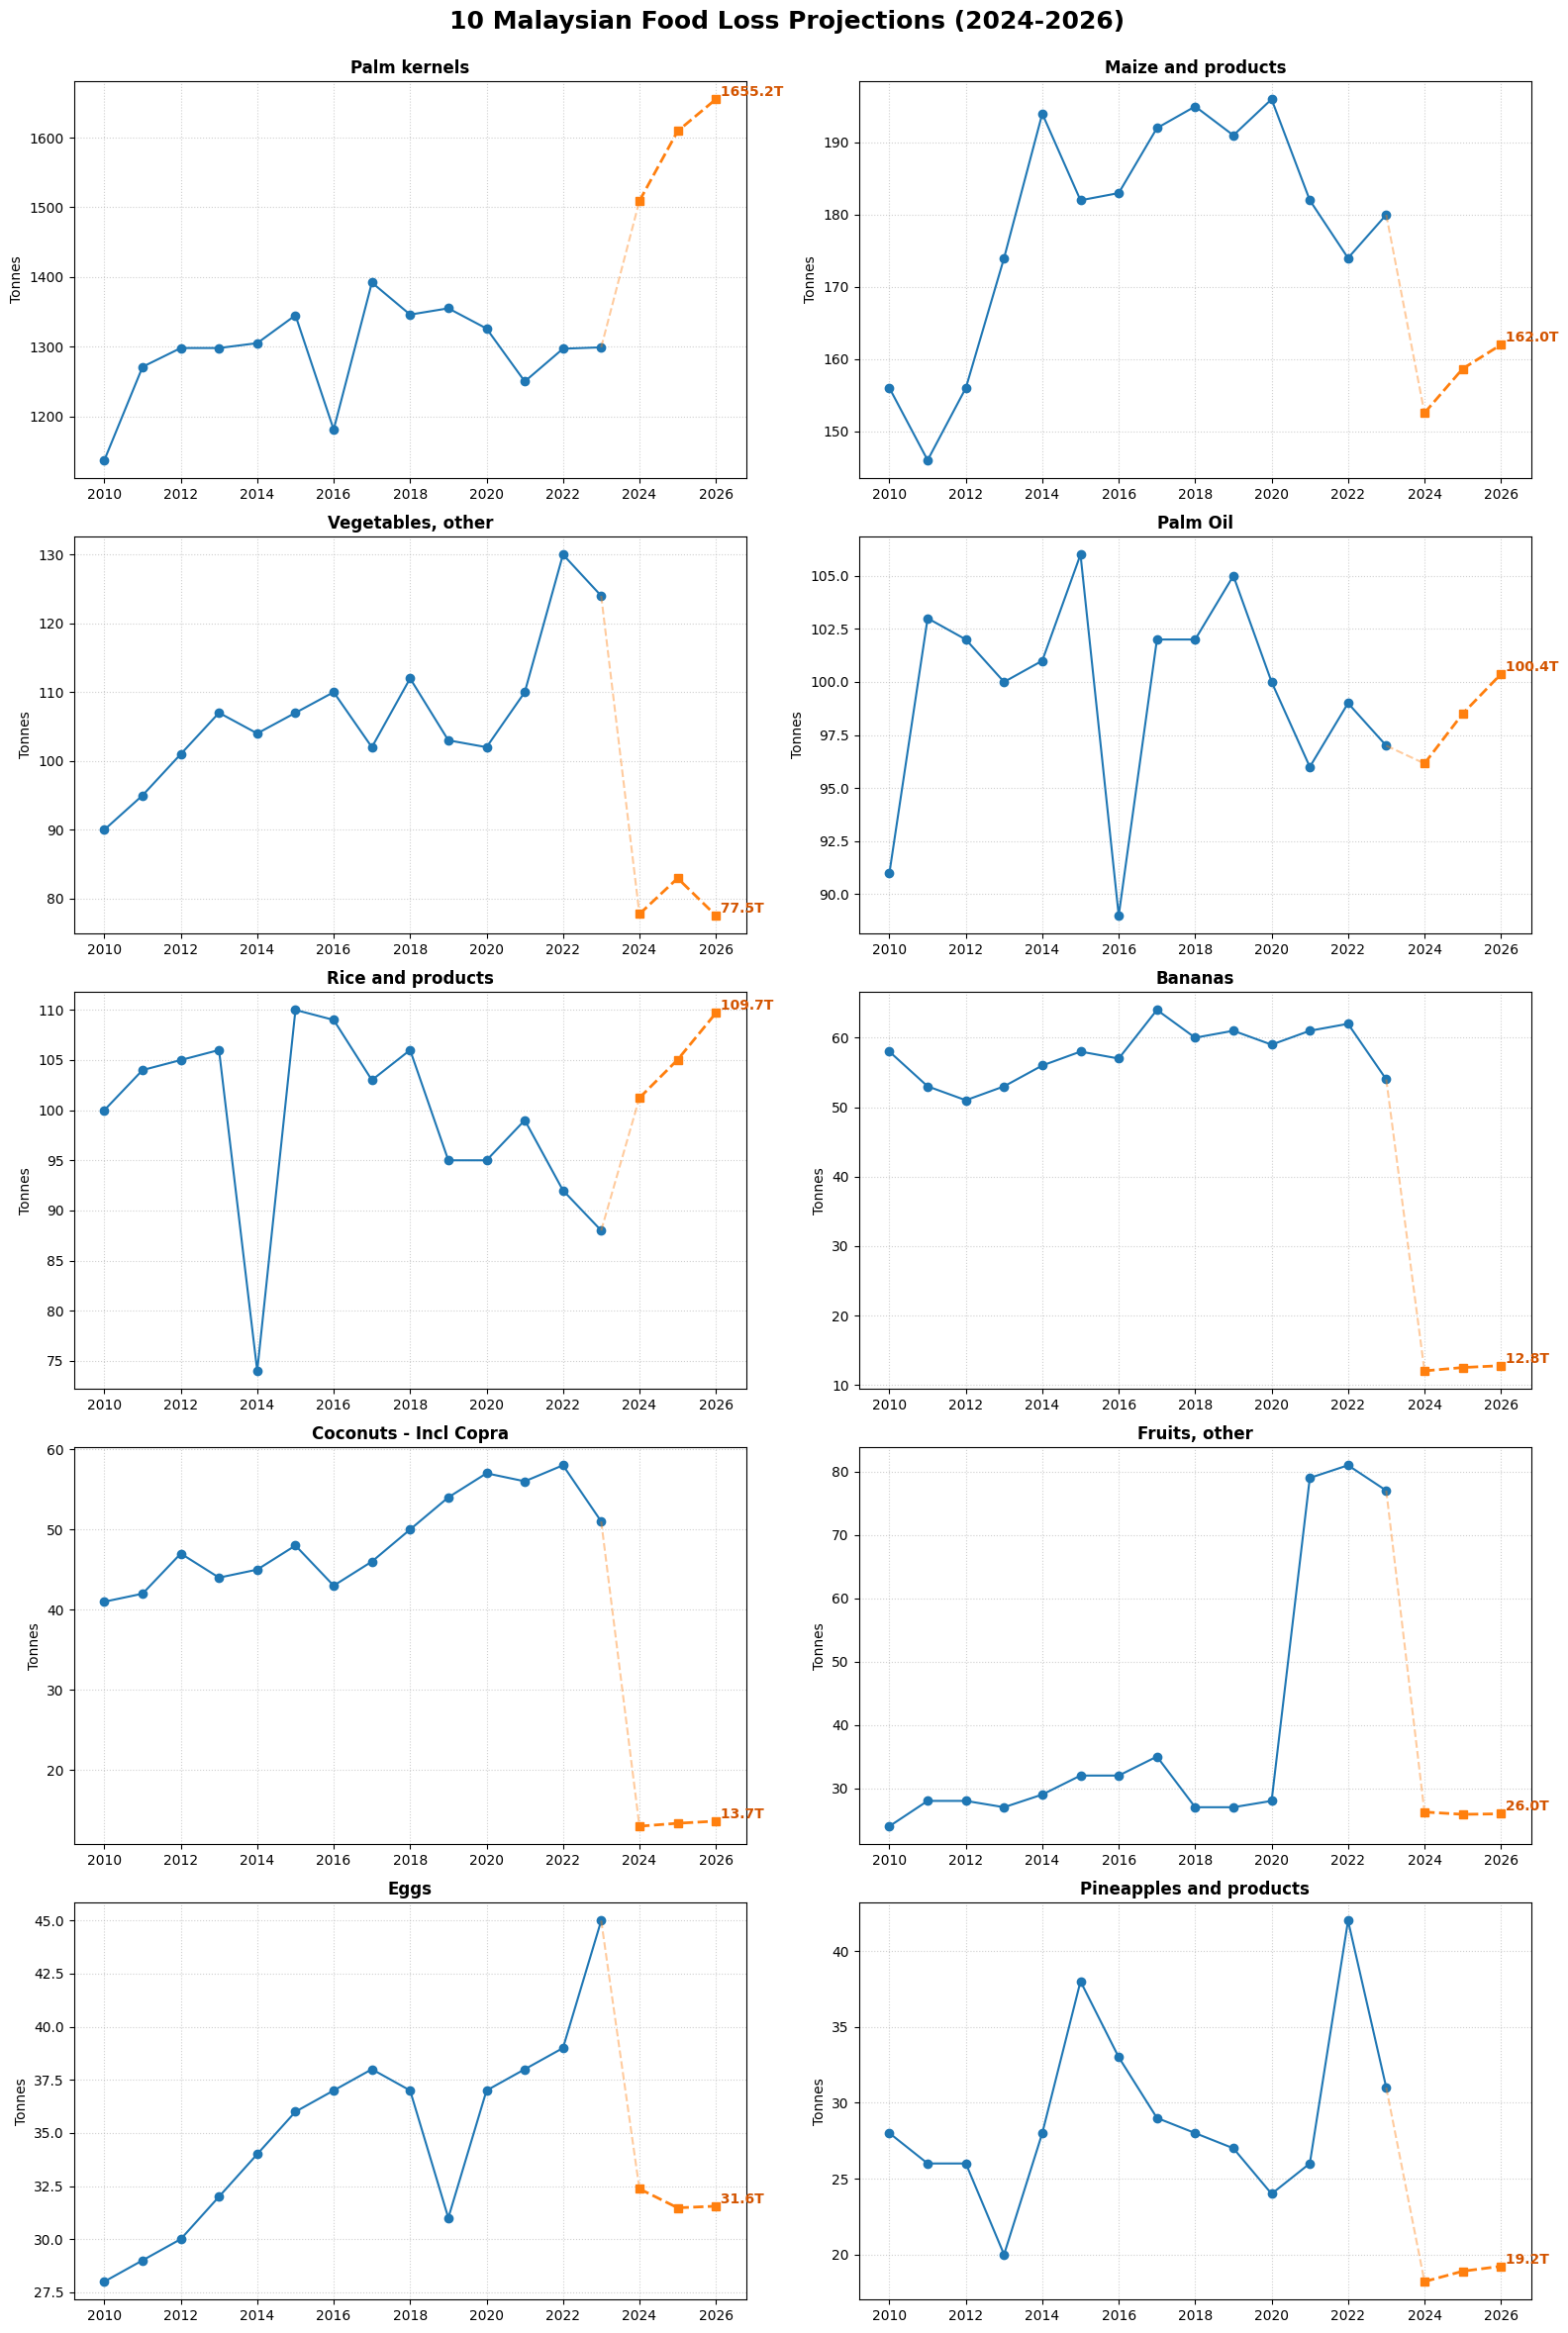

In [ ]:
nrows, ncols = 5, 2
fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(16, 24))
axes = axes.flatten()

print(f"📌 Generating Thesis Grid for: {top10_items.index.tolist()}") # Print item names for clarity

for i, item_to_predict_name in enumerate(top10_items.index):
    ax = axes[i]

    # 1. Data Filtering
    item_df = df[df["Item_Name"] == item_to_predict_name].sort_values("Year")
    raw_item_df = df_original[df_original["Item_Name"] == item_to_predict_name].sort_values("Year")

    # Check if item_df has enough data for T_IN + T_OUT
    if len(item_df) < T_IN + T_OUT:
        print(f"Skipping {item_to_predict_name}: Not enough historical data ({len(item_df)} records)")
        ax.set_title(f"{item_to_predict_name} (Insufficient Data)", fontsize=12, fontweight='bold')
        ax.axis('off') # Turn off axis for empty plots
        continue

    # 2. Safe Forecast Retrieval
    # Using the get_safe_forecast function logic
    last_seq = item_df[available_features].tail(T_IN).values
    x_input = last_seq.reshape(1, T_IN, len(available_features))

    pred_scaled = model.predict(x_input, verbose=0)
    pred_log = target_scaler.inverse_transform(pred_scaled.reshape(-1, 1)).flatten()
    pred_final = np.expm1(pred_log)

    # Apply Thesis Guardrails (Non-negativity & clipping)
    hist_max = raw_item_df["Losses"].max()
    pred_final = np.clip(pred_final, 0, hist_max * 2)

    # 3. Time Axis Setup
    hist_years = pd.to_datetime(raw_item_df["Year"]).dt.year.values
    last_year = int(hist_years[-1])
    future_years = [last_year + 1, last_year + 2, last_year + 3]

    # 4. Plotting on the specific subplot (ax)
    ax.plot(hist_years, raw_item_df["Losses"], marker='o', label='Actual', color='#1f77b4', linewidth=1.5)
    ax.plot(future_years, pred_final, marker='s', linestyle='--', label='Forecast', color='#ff7f0e', linewidth=2)

    # Connect 2023 to 2024
    ax.plot([hist_years[-1], future_years[0]], [raw_item_df["Losses"].iloc[-1], pred_final[0]],
            linestyle='--', color='#ff7f0e', alpha=0.4)

    # Formatting Subplot
    ax.set_title(f"{item_to_predict_name}", fontsize=12, fontweight='bold')
    ax.set_ylabel("Tonnes")
    ax.grid(True, linestyle=':', alpha=0.6)

    # Annotate only the final 2026 value to keep it clean
    ax.text(future_years[-1], pred_final[-1], f" {pred_final[-1]:.1f}T",
            color='#d35400', fontweight='bold', va='bottom')

# Adjust layout to prevent overlapping
plt.tight_layout()
plt.subplots_adjust(top=0.95)
fig.suptitle("10 Malaysian Food Loss Projections (2024-2026)", fontsize=18, fontweight='bold')
plt.show()

In [ ]:
from google.colab import files
import shutil
import os

output_dir = '/content/gru_hybrid_dtw_output'
zip_filename = 'gru_hybrid_dtw_output.zip'

# Create a zip archive of the directory
shutil.make_archive(os.path.splitext(zip_filename)[0], 'zip', output_dir)

print(f"Compressing '{output_dir}' into '{zip_filename}'...")
# Download the zip file
files.download(zip_filename)
print(f"✅ '{zip_filename}' is ready for download.")

Compressing '/content/gru_hybrid_dtw_output' into 'gru_hybrid_dtw_output.zip'...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ 'gru_hybrid_dtw_output.zip' is ready for download.


# Test Case

📌 Generating Forecast Grid for 27 Items...


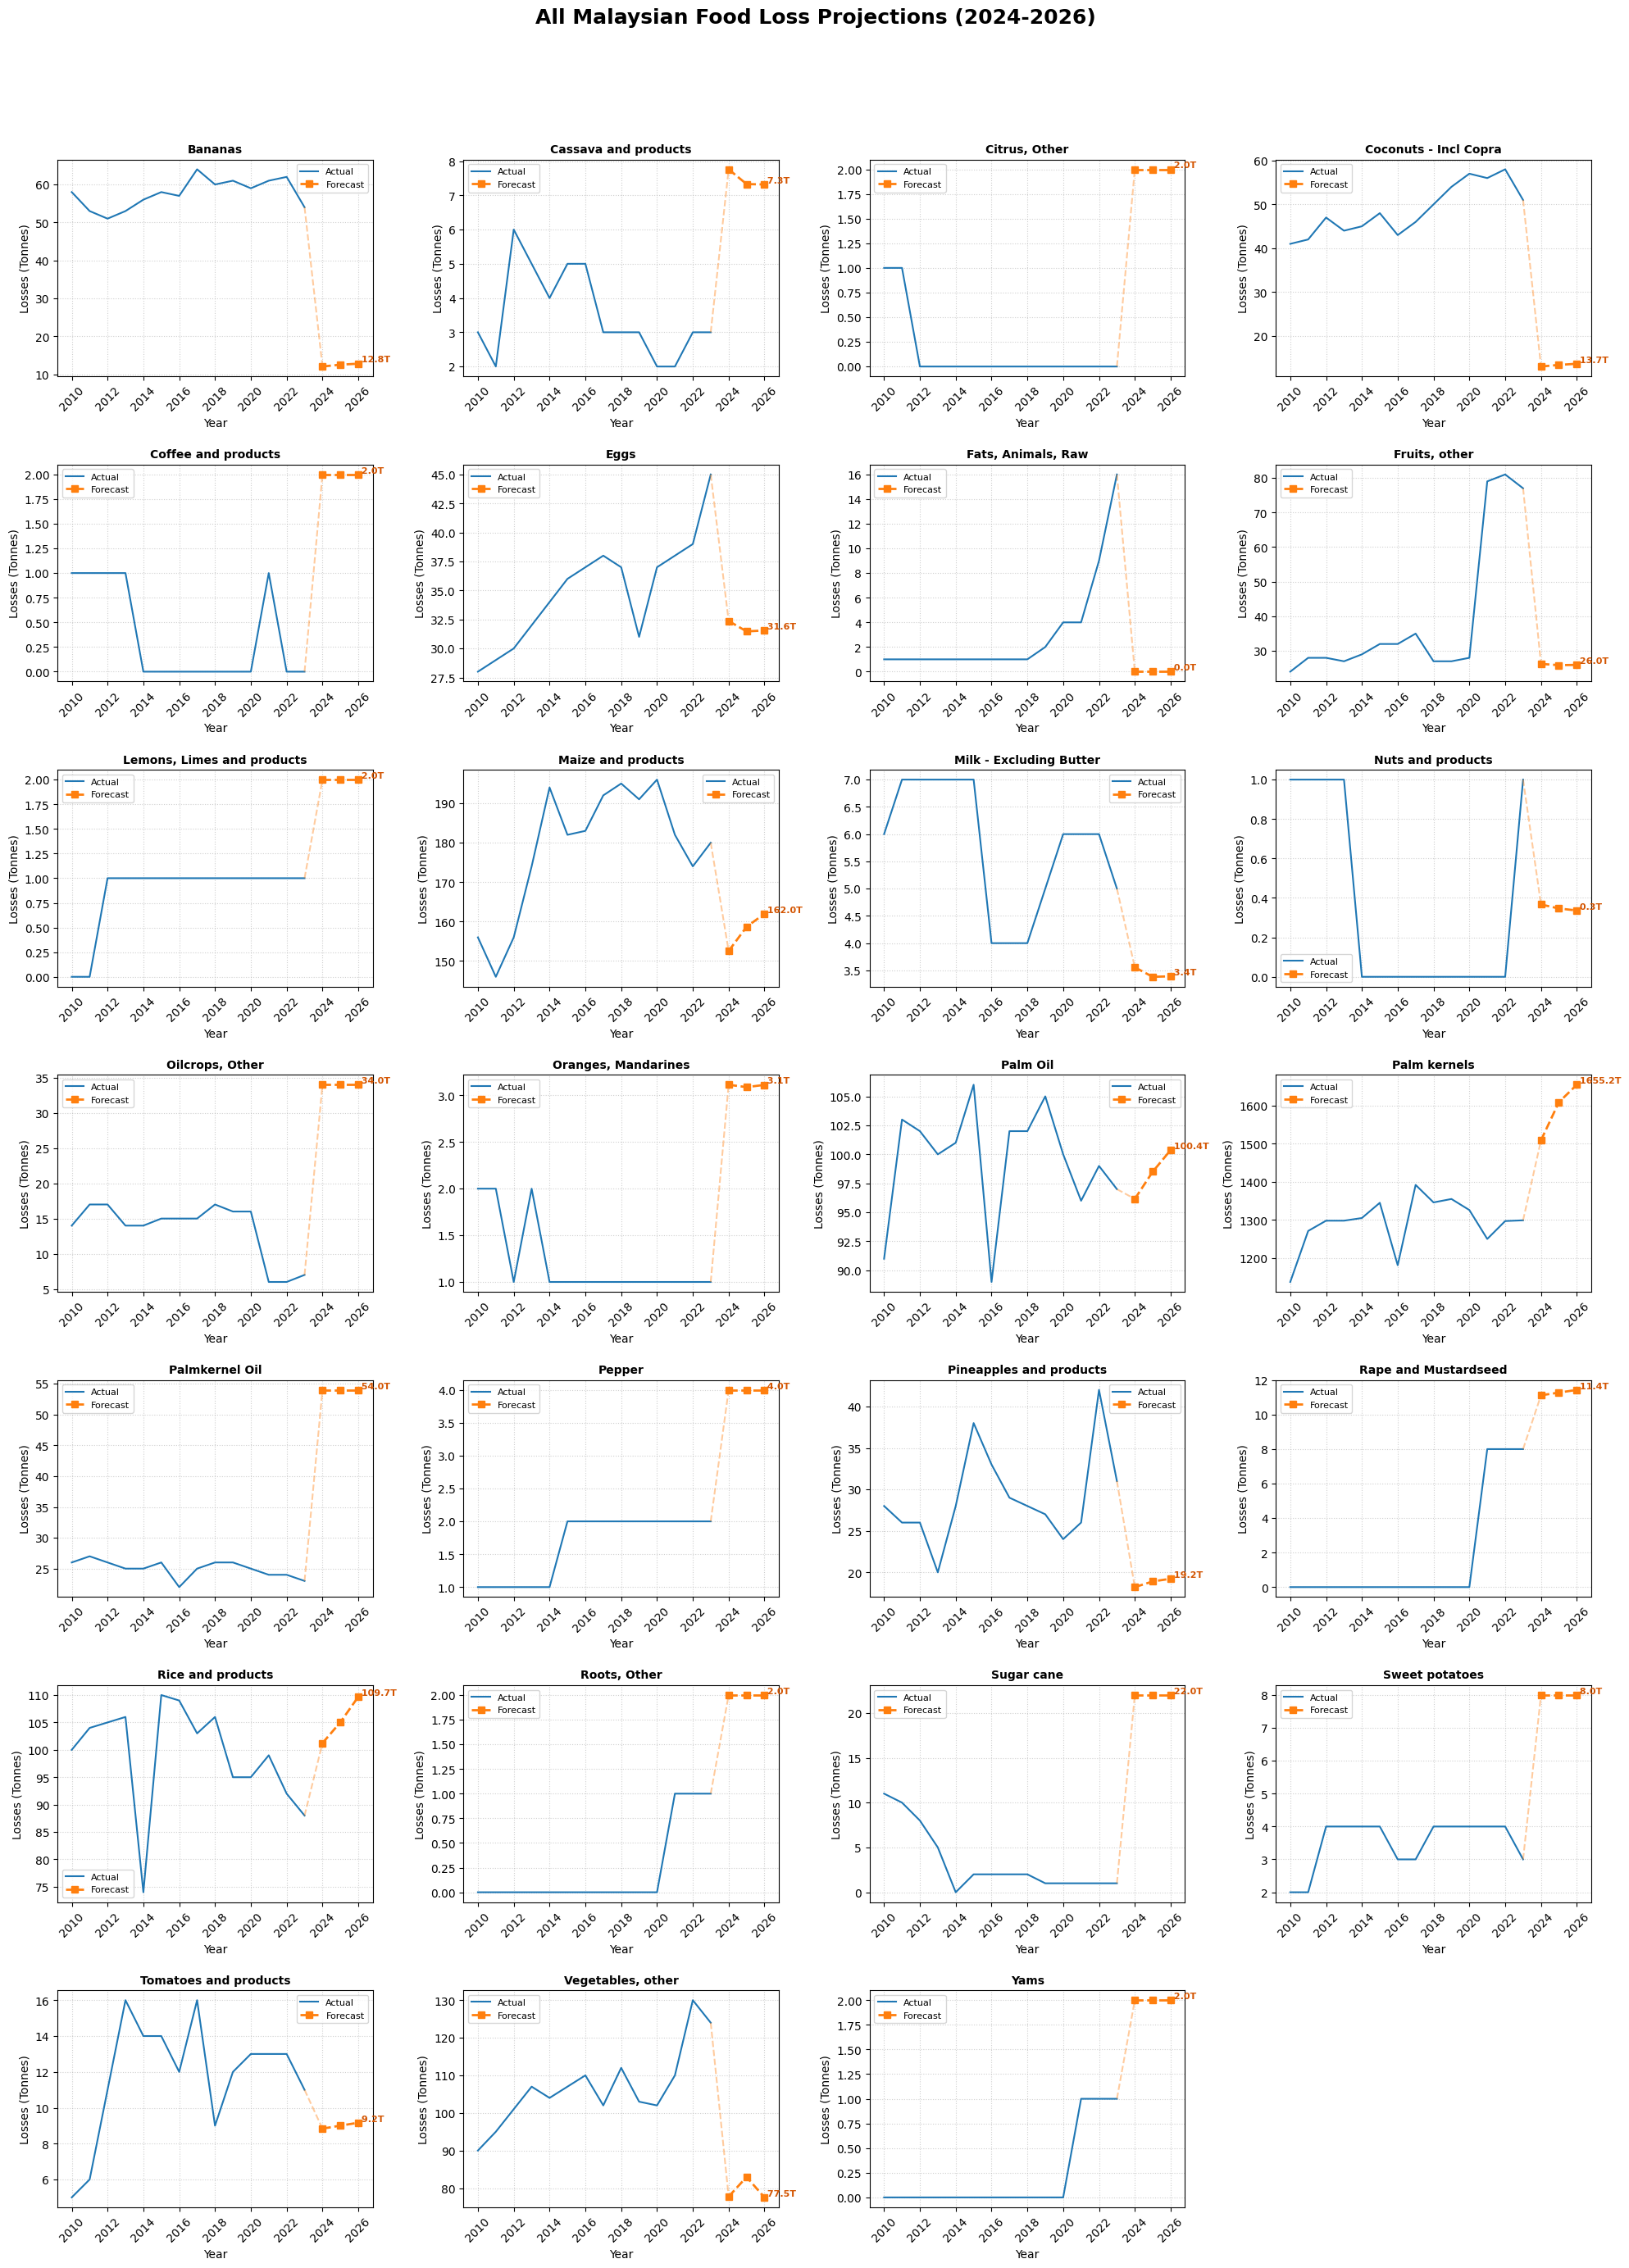

In [ ]:
unique_items = df[ID_COL].unique()
n_items = len(unique_items)

ncols = 4 # User requested 4 columns
nrows = int(np.ceil(n_items / ncols))

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(20, nrows * 4), layout='tight') # Adjusted figsize for more items
axes = axes.flatten()

print(f"📌 Generating Forecast Grid for {n_items} Items...")

for i, item_to_predict_name in enumerate(unique_items):
    ax = axes[i]

    # 1. Data Filtering
    item_df = df[df[ID_COL] == item_to_predict_name].sort_values(TIME_COL)
    raw_item_df = df_original[df_original[ID_COL] == item_to_predict_name].sort_values(TIME_COL)

    # Check if item_df has enough data for T_IN + T_OUT
    if len(item_df) < T_IN + T_OUT:
        print(f"Skipping {item_to_predict_name}: Not enough historical data ({len(item_df)} records)")
        ax.set_title(f"{item_to_predict_name} (Insufficient Data)", fontsize=10, fontweight='bold')
        ax.axis('off') # Turn off axis for empty plots
        continue

    # 2. Safe Forecast Retrieval
    last_seq = item_df[available_features].tail(T_IN).values
    x_input = last_seq.reshape(1, T_IN, len(available_features))

    pred_scaled = model.predict(x_input, verbose=0)
    pred_log = target_scaler.inverse_transform(pred_scaled.reshape(-1, 1)).flatten()
    pred_final = np.expm1(pred_log)

    # Apply Thesis Guardrails (Non-negativity & clipping)
    hist_max = raw_item_df["Losses"].max()
    pred_final = np.clip(pred_final, 0, hist_max * 2)

    # 3. Time Axis Setup
    hist_years = pd.to_datetime(raw_item_df[TIME_COL]).dt.year.values
    last_year = int(hist_years[-1])
    future_years = [last_year + 1, last_year + 2, last_year + 3]

    # 4. Plotting on the specific subplot (ax)
    ax.plot(hist_years, raw_item_df["Losses"], label="Actual", color='#1f77b4', linewidth=1.5)
    ax.plot(future_years, pred_final, marker='s', linestyle='--', label='Forecast', color='#ff7f0e', linewidth=2)

    # Connect 2023 to 2024
    ax.plot([hist_years[-1], future_years[0]], [raw_item_df["Losses"].iloc[-1], pred_final[0]],
            linestyle='--', color='#ff7f0e', alpha=0.4)

    # Formatting Subplot
    ax.set_title(f"{item_to_predict_name}", fontsize=10, fontweight='bold')
    ax.set_xlabel("Year")
    ax.set_ylabel("Losses (Tonnes)")
    ax.legend(fontsize=8)
    ax.grid(True, linestyle=':', alpha=0.6)
    ax.tick_params(axis='x', rotation=45)

    # Annotate only the final 2026 value to keep it clean
    ax.text(future_years[-1], pred_final[-1], f" {pred_final[-1]:.1f}T",
            color='#d35400', fontweight='bold', va='bottom', fontsize=8)

# Turn off any unused subplots
for i in range(n_items, len(axes)):
    fig.delaxes(axes[i])

plt.suptitle("All Malaysian Food Loss Projections (2024-2026)", fontsize=18, fontweight='bold', y=1.02)
plt.tight_layout(rect=[0, 0.03, 1, 0.98]) # Adjust layout to prevent title overlapping
plt.show()

In [ ]:
from ipywidgets import Dropdown, Output
from IPython.display import display

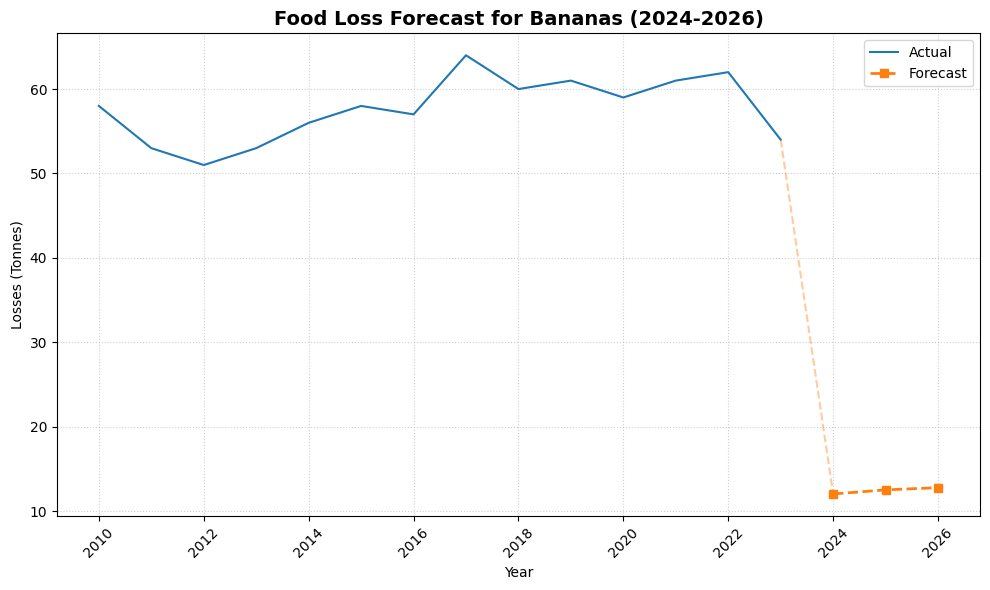

In [ ]:
unique_item_names = df[ID_COL].unique()

item_dropdown = Dropdown(
    options=unique_item_names,
    value=unique_item_names[0],
    description='Select Item:',
    disabled=False,
)
display(item_dropdown)
print("✅ Dropdown widget created and displayed.")

output_plot = Output()
display(output_plot)

def on_item_change(change):
    with output_plot:
        output_plot.clear_output(wait=True)
        item_to_predict_name = change['new'] # Changed from change.new to change['new']

        # 1. Data Filtering
        item_df = df[df[ID_COL] == item_to_predict_name].sort_values(TIME_COL)
        raw_item_df = df_original[df_original[ID_COL] == item_to_predict_name].sort_values(TIME_COL)

        # Check if item_df has enough data for T_IN + T_OUT
        if len(item_df) < T_IN + T_OUT:
            print(f"Skipping {item_to_predict_name}: Not enough historical data ({len(item_df)} records)")
            return

        # 2. Safe Forecast Retrieval
        last_seq = item_df[available_features].tail(T_IN).values
        x_input = last_seq.reshape(1, T_IN, len(available_features))

        pred_scaled = model.predict(x_input, verbose=0)
        pred_log = target_scaler.inverse_transform(pred_scaled.reshape(-1, 1)).flatten()
        pred_final = np.expm1(pred_log)

        # Apply Thesis Guardrails (Non-negativity & clipping)
        hist_max = raw_item_df["Losses"].max()
        pred_final = np.clip(pred_final, 0, hist_max * 2)

        # 3. Time Axis Setup
        hist_years = pd.to_datetime(raw_item_df[TIME_COL]).dt.year.values
        last_year = int(hist_years[-1])
        future_years = [last_year + 1, last_year + 2, last_year + 3]

        # 4. Plotting
        plt.figure(figsize=(10, 6))
        plt.plot(hist_years, raw_item_df["Losses"], label="Actual", color='#1f77b4', linewidth=1.5)
        plt.plot(future_years, pred_final, marker='s', linestyle='--', label='Forecast', color='#ff7f0e', linewidth=2)

        # Connect 2023 to 2024
        plt.plot([hist_years[-1], future_years[0]], [raw_item_df["Losses"].iloc[-1], pred_final[0]],
                 linestyle='--', color='#ff7f0e', alpha=0.4)

        # Formatting
        plt.title(f"Food Loss Forecast for {item_to_predict_name} (2024-2026)", fontsize=14, fontweight='bold')
        plt.xlabel("Year")
        plt.ylabel("Losses (Tonnes)")
        plt.legend(fontsize=10)
        plt.grid(True, linestyle=':', alpha=0.6)
        plt.tick_params(axis='x', rotation=45)
        plt.tight_layout()
        plt.show()

# Attach the function to the dropdown's observe method
item_dropdown.observe(on_item_change, names='value')

# Display the plot for the initial selected item
on_item_change({'new': item_dropdown.value})

print("✅ Plotting function linked to dropdown.")

In [ ]:
def build_attention_model_with_weights(input_shape, horizon, units=128, dr=0.4):
    encoder_inputs = Input(shape=input_shape)

    # 1. Encoder
    encoder_gru, state_h = GRU(units, return_sequences=True, return_state=True)(encoder_inputs)

    # --- GLOBAL CONTEXT BRANCH ---
    global_context = GlobalAveragePooling1D()(encoder_gru)
    global_context = Dropout(dr)(global_context)
    global_context_repeated = RepeatVector(horizon)(global_context)
    # -----------------------------

    # 2. Decoder Initial State Setup
    decoder_initial_state = Dense(units//2, activation='tanh')(state_h)
    decoder_input = RepeatVector(horizon)(decoder_initial_state)

    # 3. Decoder GRU
    decoder_gru = GRU(units//2, return_sequences=True)(decoder_input, initial_state=decoder_initial_state)

    # 4. Attention Mechanism (return_attention_scores=True)
    encoder_out_proj = TimeDistributed(Dense(units//2, activation='relu'))(encoder_gru)
    attn_output, attn_scores = Attention(name='attention_layer')([decoder_gru, encoder_out_proj], return_attention_scores=True)

    # 5. CONCATENATION: Local (Attention) + Global (Pooled) + Temporal (Decoder)
    decoder_combined = Concatenate()([decoder_gru, attn_output, global_context_repeated])
    decoder_combined = BatchNormalization()(decoder_combined)
    decoder_combined = Dropout(dr)(decoder_combined)

    # 6. Final Output (TimeDistributed for each year in horizon)
    output = TimeDistributed(Dense(1))(decoder_combined)

    # Return both the model output and the attention scores
    return Model(inputs=encoder_inputs, outputs=[output, attn_scores])

# Instantiate the new model with best parameters
best_params = study.best_params
model_with_attention = build_attention_model_with_weights(
    input_shape=(T_IN, len(available_features)),
    horizon=T_OUT,
    units=best_params['gru_units'],
    dr=best_params['dropout']
)

# Load the weights from the previously trained best model
model_with_attention.load_weights(os.path.join(SAVE_DIR, "best_model.keras"))

print("✅ Model redefined to output attention weights and weights loaded.")

# Select a single test sample for visualization
sample_idx = 0
chosen_test_sample = X_test_scaled[sample_idx:sample_idx+1]

# Get predictions and attention weights for the chosen sample
predictions, attention_weights = model_with_attention.predict(chosen_test_sample)

print(f"Predictions shape: {predictions.shape}")
print(f"Attention weights shape: {attention_weights.shape}")
print(f"Chosen test sample shape: {chosen_test_sample.shape}")

✅ Model redefined to output attention weights and weights loaded.
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
Predictions shape: (1, 3, 1)
Attention weights shape: (1, 3, 5)
Chosen test sample shape: (1, 5, 18)


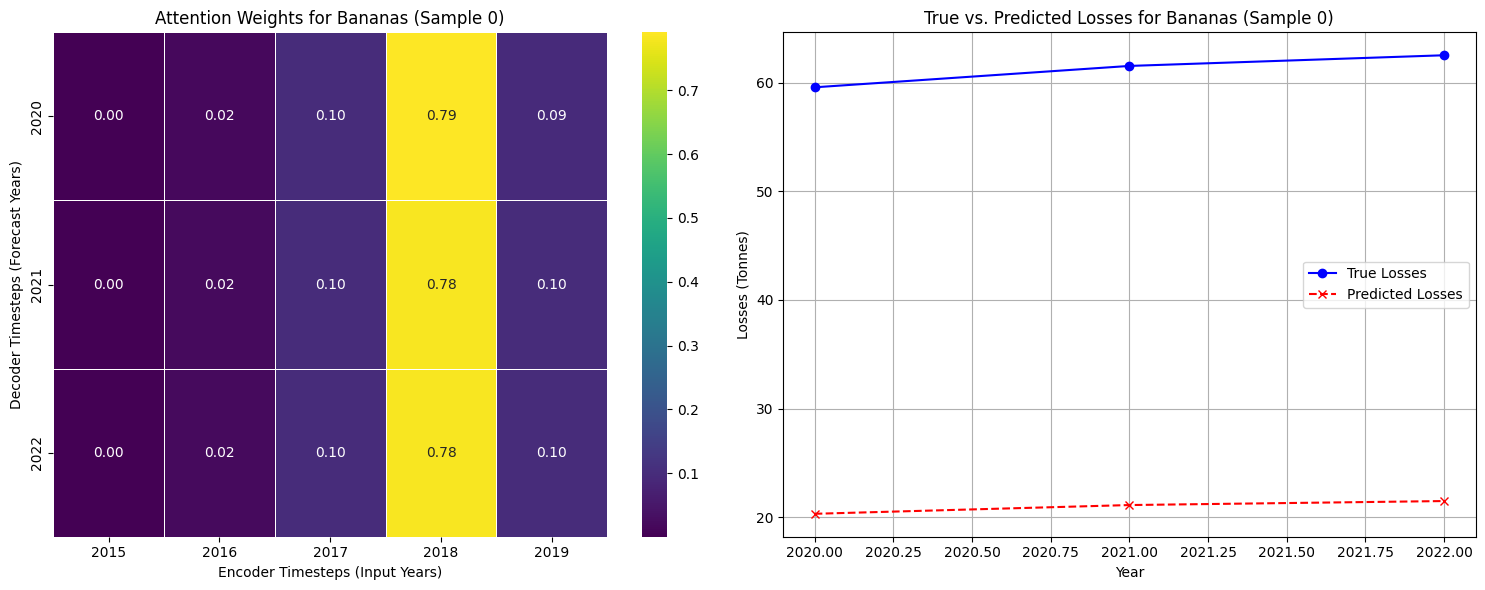

✅ Visualized attention weights and predictions for sample 0 of item Bananas.


In [ ]:
# --- 1. Get True Losses for the chosen sample (inverse transform) ---
y_true_scaled_sample = y_test_scaled[sample_idx:sample_idx+1]
y_true_log_sample = target_scaler.inverse_transform(y_true_scaled_sample.reshape(-1, 1)).flatten()
y_true_final_sample = np.expm1(y_true_log_sample)

# --- 2. Inverse Transform Predictions ---
predictions_log_sample = target_scaler.inverse_transform(predictions.reshape(-1, 1)).flatten()
predictions_final_sample = np.expm1(predictions_log_sample)

# --- 3. Prepare Attention Weights for Plotting ---
attention_weights_plot = attention_weights.squeeze()

# --- 4. Get corresponding historical years for input sequence ---
prediction_start_year = YR_te_arr[sample_idx]
input_years = np.arange(prediction_start_year - T_IN, prediction_start_year)

# Future years for target/prediction
future_years = np.arange(prediction_start_year, prediction_start_year + T_OUT)

# --- 5. Visualization ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Plot 1: Attention Weights Heatmap
sns.heatmap(
    attention_weights_plot,
    xticklabels=input_years,
    yticklabels=future_years,
    cmap='viridis',
    annot=True,
    fmt=".2f",
    linewidths=.5,
    ax=ax1
)
ax1.set_title(f'Attention Weights for {IT_te_arr[sample_idx]} (Sample {sample_idx})')
ax1.set_xlabel('Encoder Timesteps (Input Years)')
ax1.set_ylabel('Decoder Timesteps (Forecast Years)')

# Plot 2: True vs. Predicted Losses
ax2.plot(future_years, y_true_final_sample, marker='o', linestyle='-', color='blue', label='True Losses')
ax2.plot(future_years, predictions_final_sample, marker='x', linestyle='--', color='red', label='Predicted Losses')
ax2.set_title(f'True vs. Predicted Losses for {IT_te_arr[sample_idx]} (Sample {sample_idx})')
ax2.set_xlabel('Year')
ax2.set_ylabel('Losses (Tonnes)')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

print(f"✅ Visualized attention weights and predictions for sample {sample_idx} of item {IT_te_arr[sample_idx]}.")